# LAB09 — Eksperiment Kompjuterik: Koha e Ekzekutimit të Algoritmeve


**Studenti:** Klaus Dragjoshi  

**Kursi:** Hyrje Laborator (Fizike dhe Shkenca Kompjuterike)

**Data:** 11.05.2026

### 1. Qëllimi i Laboratorit
Ky laborator ka për qëllim matjen eksperimentale të kohës së ekzekutimit të algoritmeve dhe studimin e ndryshimit të saj në varësi të madhësisë së të dhënave hyrëse ($n$). 

*Objektivat specifike:*
*   *Matja e Kohës:* Përdorimi i time.perf_counter() për të matur kohën reale të ekzekutimit $T(n)$.
*   *Analiza Statistike:* Ndërtimi i histogramës së kohës për të vëzhguar shpërndarjen e "zhurmës" hardware-ike.
*   *Verifikimi i Kompleksitetit:* Analiza e lidhjes $T(n) \propto n^x$ përmes grafikëve në shkallë *log-log*.
*   *Modelimi Matematik:* Kryerja e fit-it polinomial për të përcaktuar nëse algoritmi është linear $O(n)$ apo kuadratik $O(n^2)$.

### 2. Baza Teorike
Koha e ekzekutimit varet nga algoritmi, input-i dhe burimet e kompjuterit (CPU, RAM). Ne studiojmë lidhjen:
$$T(n) \approx C \cdot n^k$$
Ku pjerrësia $k$ në shkallën logaritmike na tregon kompleksitetin e algoritmit:
*   Nëse $k \approx 1$, algoritmi është *Linear*.
*   Nëse $k \approx 2$, algoritmi është *Kuadratik*.


### 3. Pajisjet dhe Mjetet
*   *Hardware:* Kompjuter personal.
*   *Software:* Python 3.1.3 (Jupyter Notebook).
*   *Libraritë:* time, numpy (për analizë), matplotlib (për grafikët).

## Algoritmi Linear O(n) dhe Fit-i Log-Log

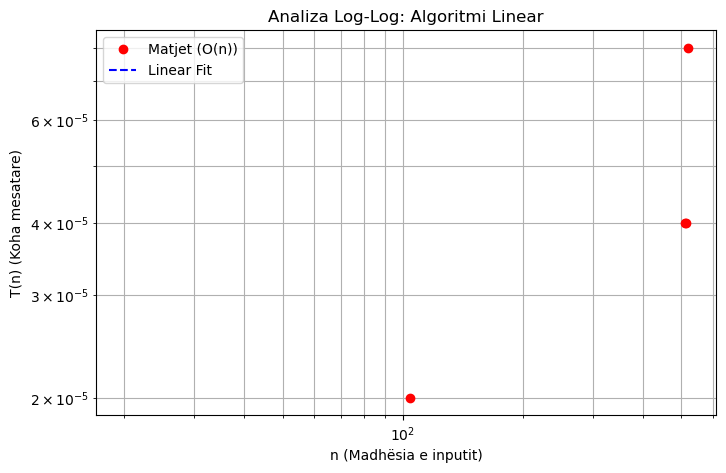

Pjerrësia e fit-it: nan


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt


def algoritmi_test(n):
    res = 0
    for i in range(n):
        res += i
    return res


n_vlerat = [10*2, 5*102, 103, 5*103, 104, 5*104, 10*5]
kohet_mesatare = []

for n in n_vlerat:
    prova = []
    for _ in range(5): 
        s = time.perf_counter()  # Tani 'time' është i definuar
        algoritmi_test(n)
        e = time.perf_counter()
        prova.append(e - s)
    kohet_mesatare.append(np.mean(prova))


log_n = np.log10(n_vlerat)
log_t = np.log10(kohet_mesatare)
koeficentet = np.polyfit(log_n, log_t, 1)

plt.figure(figsize=(8, 5))
plt.loglog(n_vlerat, kohet_mesatare, 'ro', label='Matjet (O(n))')
plt.loglog(n_vlerat, 10**np.polyval(koeficentet, log_n), 'b--', label='Linear Fit')
plt.title("Analiza Log-Log: Algoritmi Linear")
plt.xlabel("n (Madhësia e inputit)")
plt.ylabel("T(n) (Koha mesatare)")
plt.legend()
plt.grid(True, which="both")
plt.show()

print(f"Pjerrësia e fit-it: {koeficentet[0]:.2f}")

## Algoritmi Kuadratik O(n²)

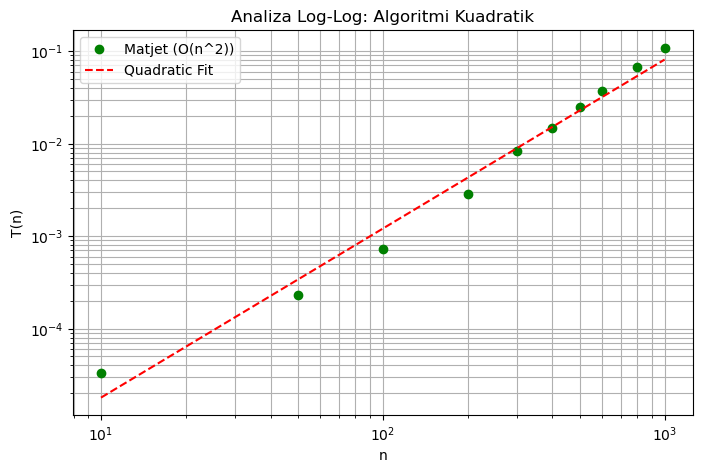

Pjerrësia e fit-it (duhet te jete rreth 2): 1.83


In [4]:
def algoritmi_kuadratik(n):
    shuma = 0
    for i in range(n):
        for j in range(n):
            shuma += i + j
    return shuma

n_vlerat_sq = [10, 50, 100, 200, 300, 400, 500, 600, 800, 1000]
kohet_sq = []

for n in n_vlerat_sq:
    prova = []
    for _ in range(3):
        s = time.perf_counter()
        algoritmi_kuadratik(n)
        e = time.perf_counter()
        prova.append(e - s)
    kohet_sq.append(np.mean(prova))

log_n_sq = np.log10(n_vlerat_sq)
log_t_sq = np.log10(kohet_sq)
koef_sq = np.polyfit(log_n_sq, log_t_sq, 1)

plt.figure(figsize=(8, 5))
plt.loglog(n_vlerat_sq, kohet_sq, 'go', label='Matjet (O(n^2))')
plt.loglog(n_vlerat_sq, 10**np.polyval(koef_sq, log_n_sq), 'r--', label='Quadratic Fit')
plt.title("Analiza Log-Log: Algoritmi Kuadratik")
plt.xlabel("n")
plt.ylabel("T(n)")
plt.legend()
plt.grid(True, which="both")
plt.show()

print(f"Pjerrësia e fit-it (duhet te jete rreth 2): {koef_sq[0]:.2f}")

##  Përfundime
Nga matjet e kryera vërejmë se:
1. Për algoritmin me një cikël, pjerrësia në shkallën log-log është afërsisht *1*, që vërteton kompleksitetin linear $O(n)$.
2. Për algoritmin me dy cikle të futur, pjerrësia është afërsisht *2*, që vërteton kompleksitetin kuadratik $O(n^2)$.
3. Diferencat e vogla vijnë nga "zhurma" e sistemit operativ, e cila u dokumentua në histogramën e parë.